# Hack-o-Week — Weeks 5 & 6
## Linear Algebra · Calculus (the maths behind every ML model)

**Dataset:** `student_habits_performance.csv`

Weeks 3–4 gave you the tools. This notebook explains *why the tools work*. Everything here
is **intuition-level with working code** — you will see each concept as a picture and as a
NumPy computation on the real dataset, not as a proof.

### Roadmap
| Part | Topic | Why an ML student needs it |
|---|---|---|
| A | Vectors | a student *is* a vector; similarity = dot product |
| B | Matrices | a dataset *is* a matrix; a prediction is `X @ w` |
| C | Eigenvalues & PCA | finding the directions your data actually varies along |
| D | Derivatives & gradients | how a model knows which way to improve |
| E | Chain rule | backpropagation, from first principles |
| F | Gradient descent | training a model with nothing but NumPy |

### 0 · Setup

In [1]:
import os
import numpy as np
import pandas as pd

FILENAME = "student_habits_performance.csv"

# Works whether you run this notebook from the repo (notebooks/ folder),
# from the repo root, or in Google Colab.
CANDIDATES = [
    FILENAME,
    os.path.join("data", FILENAME),
    os.path.join("..", "data", FILENAME),
    os.path.join("/content", FILENAME),
]

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:  # running in Colab without the repo -> upload the CSV once
        from google.colab import files
        print("CSV not found. Please upload student_habits_performance.csv")
        files.upload()
        DATA_PATH = FILENAME
    except ImportError:
        raise FileNotFoundError(
            "Put student_habits_performance.csv in a data/ folder next to this notebook."
        )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", df.shape)
df.head()

Loaded: ../data/student_habits_performance.csv | shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("plotting configured")

plotting configured


---
# Part A · Vectors

A **vector** is an ordered list of numbers. In ML it is a *point in space* and a *direction*
at the same time.

One row of our dataset **is** a vector:

$$
\mathbf{x} = \begin{bmatrix} \text{study hrs} \\ \text{sleep hrs} \\ \text{social media} \\ \text{netflix} \\ \text{attendance} \end{bmatrix} \in \mathbb{R}^5
$$

Every student in the dataset is a point in this 5-dimensional space. Students with similar
habits sit close together — that idea alone powers KNN, K-Means and recommender systems.

In [3]:
FEATURES = ["study_hours_per_day", "sleep_hours", "social_media_hours",
            "netflix_hours", "attendance_percentage"]

X = df[FEATURES].to_numpy(dtype=float)
y = df["exam_score"].to_numpy(dtype=float)

x1 = X[0]     # student S1000 as a vector
x2 = X[1]     # student S1001

print("Student 0 vector:", x1)
print("Student 1 vector:", x2)
print("dimension (how many numbers describe one student):", x1.shape[0])

Student 0 vector: [ 0.   8.   1.2  1.1 85. ]
Student 1 vector: [ 6.9  4.6  2.8  2.3 97.3]
dimension (how many numbers describe one student): 5


## A1 · Magnitude (norm) and unit vectors

The **length** of a vector is its L2 norm:

$$\|\mathbf{x}\|_2 = \sqrt{x_1^2 + x_2^2 + \dots + x_n^2}$$

A **unit vector** $\hat{\mathbf{x}} = \mathbf{x}/\|\mathbf{x}\|$ has length 1 — it keeps
the *direction* and throws away the *magnitude*.

You will meet the L1 norm ($\sum|x_i|$) again in Week 7 — it is what makes Lasso do
feature selection.

In [4]:
print("x1              :", x1)
print("L2 norm (manual):", np.sqrt(np.sum(x1 ** 2)).round(4))
print("L2 norm (numpy) :", np.linalg.norm(x1).round(4))
print("L1 norm         :", np.linalg.norm(x1, ord=1).round(4))

u1 = x1 / np.linalg.norm(x1)
print("\nunit vector     :", u1.round(4))
print("its length      :", np.linalg.norm(u1).round(10), "  <- always 1")

x1              : [ 0.   8.   1.2  1.1 85. ]
L2 norm (manual): 85.3912
L2 norm (numpy) : 85.3912
L1 norm         : 95.3

unit vector     : [0.     0.0937 0.0141 0.0129 0.9954]
its length      : 1.0   <- always 1


## A2 · Vector arithmetic, drawn

- **Addition** $\mathbf{a}+\mathbf{b}$: walk along `a`, then along `b` (tip to tail).
- **Scalar multiplication** $c\mathbf{a}$: stretch (|c|>1), shrink (|c|<1) or flip (c<0).
- **Subtraction** $\mathbf{a}-\mathbf{b}$: the arrow that points *from* b *to* a — this is
  the "difference between two students".

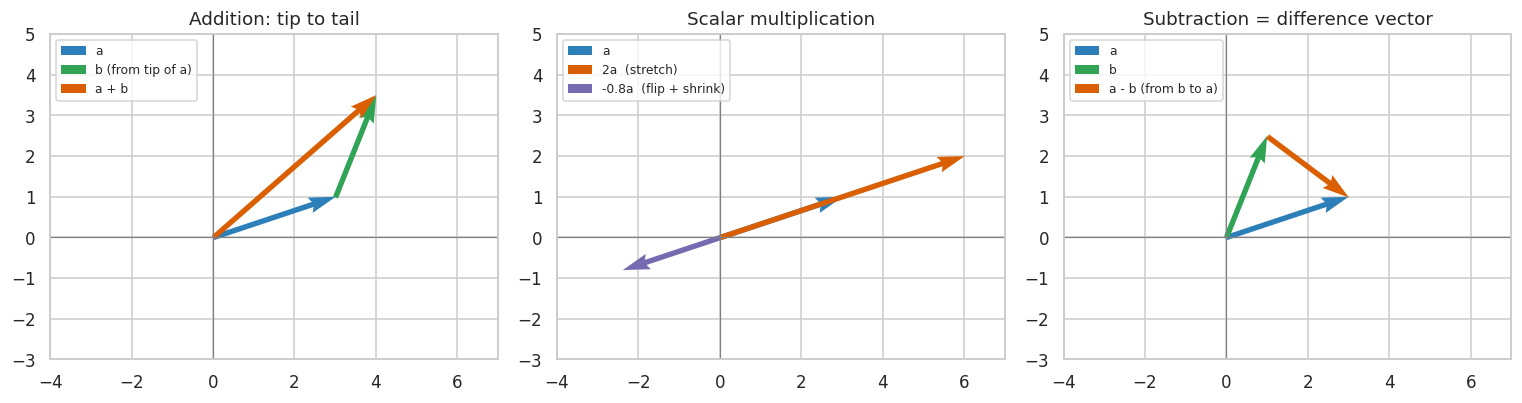

In [5]:
a = np.array([3.0, 1.0])
b = np.array([1.0, 2.5])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

def arrow(ax, vec, color, label, start=(0, 0)):
    ax.quiver(start[0], start[1], vec[0], vec[1], angles="xy",
              scale_units="xy", scale=1, color=color, width=0.012, label=label)

# addition
arrow(axes[0], a, "#2c7fb8", "a")
arrow(axes[0], b, "#31a354", "b (from tip of a)", start=a)
arrow(axes[0], a + b, "#d95f02", "a + b")
axes[0].set_title("Addition: tip to tail")

# scalar multiplication
arrow(axes[1], a, "#2c7fb8", "a")
arrow(axes[1], 2 * a, "#d95f02", "2a  (stretch)")
arrow(axes[1], -0.8 * a, "#756bb1", "-0.8a  (flip + shrink)")
axes[1].set_title("Scalar multiplication")

# subtraction
arrow(axes[2], a, "#2c7fb8", "a")
arrow(axes[2], b, "#31a354", "b")
arrow(axes[2], a - b, "#d95f02", "a - b (from b to a)", start=b)
axes[2].set_title("Subtraction = difference vector")

for ax in axes:
    ax.set_xlim(-4, 7); ax.set_ylim(-3, 5)
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_aspect("equal"); ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

## A3 · The dot product

$$\mathbf{a}\cdot\mathbf{b} = \sum_i a_i b_i = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta$$

Two readings of the same number:

- **Algebraic**: multiply matching entries and add them up.
- **Geometric**: how much of `a` points along `b`, scaled by both lengths.

| Dot product | Angle | Meaning |
|---|---|---|
| large positive | θ ≈ 0° | same direction |
| ≈ 0 | θ = 90° | **orthogonal** — unrelated |
| large negative | θ ≈ 180° | opposite directions |

**This is the most important operation in machine learning.** A linear model's prediction
is literally a dot product: $\hat{y} = \mathbf{w}\cdot\mathbf{x} + b$.

In [6]:
print("manual dot:", sum(i * j for i, j in zip(x1, x2)).round(3))
print("np.dot    :", np.dot(x1, x2).round(3))
print("@ operator:", (x1 @ x2).round(3), "  <- preferred, reads like maths")

# The angle between two students
cos_theta = (x1 @ x2) / (np.linalg.norm(x1) * np.linalg.norm(x2))
print(f"\ncos(theta) = {cos_theta:.4f}  ->  theta = {np.degrees(np.arccos(cos_theta)):.2f} degrees")

# Orthogonality demo
p, q = np.array([2.0, 0.0]), np.array([0.0, 5.0])
print("\northogonal example  p . q =", p @ q, "(exactly 0 -> 90 degrees)")

manual dot: 8313.19
np.dot    : 8313.19
@ operator: 8313.19   <- preferred, reads like maths

cos(theta) = 0.9963  ->  theta = 4.96 degrees

orthogonal example  p . q = 0.0 (exactly 0 -> 90 degrees)


### Cosine similarity: "which student is most like me?"

Raw dot products are dominated by whichever feature has the biggest numbers
(here `attendance_percentage`, which is ~85 while sleep is ~7). So we **standardise
first** — subtract the mean, divide by the standard deviation — then compare *directions*
with cosine similarity.

In [7]:
# Standardise (z-score) so every feature contributes on the same scale
Xz = (X - X.mean(axis=0)) / X.std(axis=0)

def cosine_similarity(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

target_idx = 1
target = Xz[target_idx]

sims = np.array([cosine_similarity(target, row) for row in Xz])
sims[target_idx] = -np.inf                  # exclude the student themself
nearest = np.argsort(sims)[::-1][:5]

print(f"Reference student: {df.loc[target_idx, 'student_id']} "
      f"(score {y[target_idx]})")
print(df.loc[target_idx, FEATURES].to_dict())
print("\n5 most similar students by cosine similarity:\n")
out = df.loc[nearest, ["student_id"] + FEATURES + ["exam_score"]].copy()
out.insert(1, "cos_sim", sims[nearest].round(3))
print(out.to_string(index=False))

Reference student: S1001 (score 100.0)
{'study_hours_per_day': 6.9, 'sleep_hours': 4.6, 'social_media_hours': 2.8, 'netflix_hours': 2.3, 'attendance_percentage': 97.3}

5 most similar students by cosine similarity:

student_id  cos_sim  study_hours_per_day  sleep_hours  social_media_hours  netflix_hours  attendance_percentage  exam_score
     S1875    0.984                  7.6          4.8                 3.0            2.9                   99.4       100.0
     S1634    0.965                  3.8          6.3                 2.5            1.8                   85.0        76.8
     S1565    0.955                  5.1          5.0                 2.5            2.4                   90.3        79.3
     S1337    0.948                  5.3          5.2                 2.2            1.7                   92.0        93.1
     S1049    0.934                  6.1          5.8                 2.5            2.3                  100.0        96.5


similarity matrix shape: (1000, 1000)
diagonal is all 1 (each student vs itself): True
matches the loop version: True


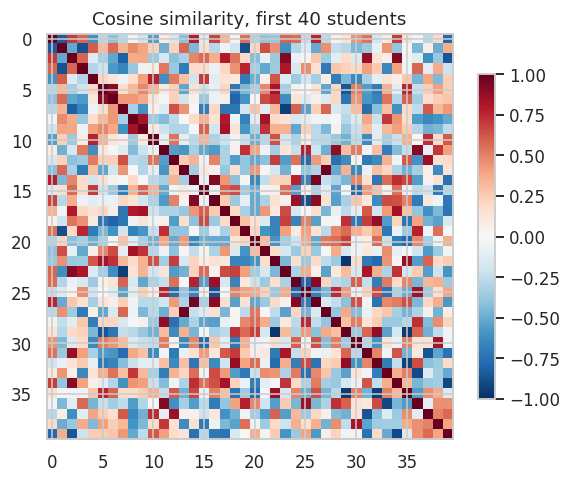

In [8]:
# Vectorised version of the same computation — no Python loop at all.
# Normalise every row to unit length, then ONE matrix product gives all pairs.
norms = np.linalg.norm(Xz, axis=1, keepdims=True)   # (1000,1)
Xu = Xz / norms                                     # unit rows
S = Xu @ Xu.T                                       # (1000,1000) similarity matrix

print("similarity matrix shape:", S.shape)
print("diagonal is all 1 (each student vs itself):", np.allclose(np.diag(S), 1))
print("matches the loop version:", np.allclose(S[target_idx][nearest], sims[nearest]))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(S[:40, :40], cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Cosine similarity, first 40 students")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); plt.show()

### Projection — the idea behind least squares

The **projection** of `a` onto `b` is the shadow `a` casts on `b`'s direction:

$$\text{proj}_{\mathbf{b}}(\mathbf{a}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}\,\mathbf{b}$$

Linear regression is exactly this: project the target vector `y` onto the space spanned by
your feature columns. The leftover piece — the part that cannot be explained — is the
**residual**, and it is orthogonal to the projection.

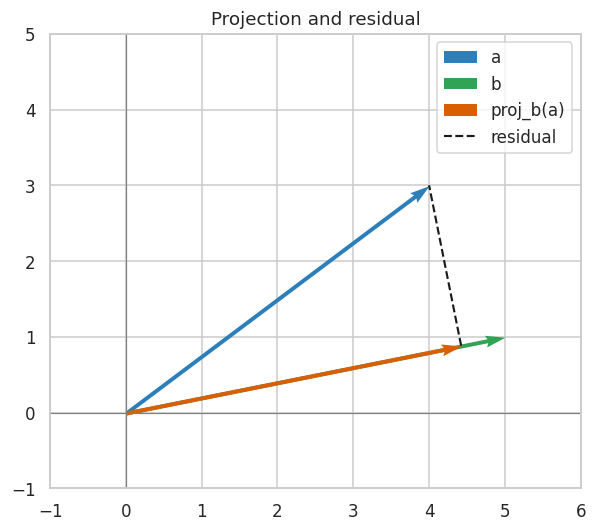

residual . b = -0.0  <- exactly 0: residual is ORTHOGONAL to b


In [9]:
a = np.array([4.0, 3.0])
b = np.array([5.0, 1.0])

proj = (a @ b) / (b @ b) * b
residual = a - proj

fig, ax = plt.subplots(figsize=(6, 5))
ax.quiver(0, 0, *a, angles="xy", scale_units="xy", scale=1, color="#2c7fb8", label="a")
ax.quiver(0, 0, *b, angles="xy", scale_units="xy", scale=1, color="#31a354", label="b")
ax.quiver(0, 0, *proj, angles="xy", scale_units="xy", scale=1, color="#d95f02",
          label="proj_b(a)")
ax.plot([proj[0], a[0]], [proj[1], a[1]], "k--", lw=1.4, label="residual")
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.legend(); ax.set_title("Projection and residual")
fig.tight_layout(); plt.show()

print("residual . b =", round(residual @ b, 12), " <- exactly 0: residual is ORTHOGONAL to b")

---
# Part B · Matrices

A **matrix** is a rectangular grid — a stack of row vectors, or a row of column vectors.

Our whole dataset is one matrix:

$$X \in \mathbb{R}^{1000 \times 5} \quad \text{(1000 students, 5 features)}$$

By convention in ML: **rows = samples, columns = features**. Getting this backwards is
the source of half of all shape errors you will ever hit.

In [10]:
print("X shape:", X.shape, " -> 1000 students x 5 features")
print("\nFirst 3 rows:\n", X[:3])
print("\nX.T shape:", X.T.shape, " -> transpose flips rows and columns")
print("\nA feature column is X[:, 0]:", X[:5, 0])
print("A sample row is X[0, :]   :", X[0, :])

X shape: (1000, 5)  -> 1000 students x 5 features

First 3 rows:
 [[ 0.   8.   1.2  1.1 85. ]
 [ 6.9  4.6  2.8  2.3 97.3]
 [ 1.4  8.   3.1  1.3 94.8]]

X.T shape: (5, 1000)  -> transpose flips rows and columns

A feature column is X[:, 0]: [0.  6.9 1.4 1.  5. ]
A sample row is X[0, :]   : [ 0.   8.   1.2  1.1 85. ]


## B1 · Matrix–vector product = making predictions

$$X\mathbf{w} = \hat{\mathbf{y}}$$

Each **row** of `X` gets dot-producted with the weight vector `w`, giving one prediction.
Shapes: `(1000,5) @ (5,) -> (1000,)`. **The inner dimensions must match.**

So "run a linear model on 1000 students" is *one matrix multiplication*.

In [11]:
# A hand-picked weight vector, just to see the mechanics
w = np.array([8.0, 1.5, -2.0, -1.5, 0.3])
bias = 30.0

y_hat = X @ w + bias                     # broadcasting adds the bias to every prediction

print("shapes:", X.shape, "@", w.shape, "->", y_hat.shape)
print("\nfirst 5 predictions:", y_hat[:5].round(2))
print("first 5 actual      :", y[:5])
print("\nCheck row 0 by hand:", (X[0] * w).sum() + bias)

mse = np.mean((y - y_hat) ** 2)
print(f"\nMSE of these hand-picked weights: {mse:.2f}  (we will do far better in Part F)")

shapes: (1000, 5) @ (5,) -> (1000,)

first 5 predictions: [ 63.45 112.24  73.49  63.8   95.07]
first 5 actual      : [ 56.2 100.   34.3  26.8  66.4]

Check row 0 by hand: 63.45

MSE of these hand-picked weights: 332.64  (we will do far better in Part F)


## B2 · Matrix–matrix product

$$(AB)_{ij} = \sum_k A_{ik}B_{kj}$$

Row `i` of `A` dotted with column `j` of `B`. Rules to memorise:

- `(m,n) @ (n,p) -> (m,p)` — the inner `n` must match and disappears.
- $AB \neq BA$ — matrix multiplication is **not** commutative.
- `A @ B` is matrix product; `A * B` is elementwise. Different operations entirely.

In [12]:
A = np.array([[1., 2.], [3., 4.], [5., 6.]])   # (3,2)
B = np.array([[7., 8., 9.], [10., 11., 12.]])  # (2,3)

print("A", A.shape, "@ B", B.shape, "->", (A @ B).shape)
print(A @ B)
print("\nB @ A ->", (B @ A).shape, "  (different shape AND different numbers)")
print(B @ A)

C = np.array([[1., 2.], [3., 4.]])
D = np.array([[5., 6.], [7., 8.]])
print("\nC @ D (matrix):\n", C @ D)
print("C * D (elementwise):\n", C * D)

A (3, 2) @ B (2, 3) -> (3, 3)
[[ 27.  30.  33.]
 [ 61.  68.  75.]
 [ 95. 106. 117.]]

B @ A -> (2, 2)   (different shape AND different numbers)
[[ 76. 100.]
 [103. 136.]]

C @ D (matrix):
 [[19. 22.]
 [43. 50.]]
C * D (elementwise):
 [[ 5. 12.]
 [21. 32.]]


In [13]:
# The single most important matrix product in classical ML: the Gram matrix X^T X
G = X.T @ X
print("X.T @ X shape:", G.shape, " -> (5,5), one entry per pair of FEATURES")
print(np.round(G, 1))

# The covariance matrix is the centred, scaled version of it
Xc = X - X.mean(axis=0)
cov = (Xc.T @ Xc) / (len(X) - 1)
print("\nCovariance matrix (manual):\n", np.round(cov, 2))
print("\nmatches np.cov:", np.allclose(cov, np.cov(X, rowvar=False)))

X.T @ X shape: (5, 5)  -> (5,5), one entry per pair of FEATURES
[[1.4758700e+04 2.2919600e+04 8.9297000e+03 6.4110000e+03 2.9903820e+05]
 [2.2919600e+04 4.3364700e+04 1.6237000e+04 1.1772400e+04 5.4449890e+05]
 [8.9297000e+03 1.6237000e+04 7.6507000e+03 4.5737000e+03 2.1123760e+05]
 [6.4110000e+03 1.1772400e+04 4.5737000e+03 4.4660000e+03 1.5307330e+05]
 [2.9903820e+05 5.4449890e+05 2.1123760e+05 1.5307330e+05 7.1664004e+06]]

Covariance matrix (manual):
 [[ 2.160e+00 -5.000e-02  3.000e-02 -5.000e-02  3.600e-01]
 [-5.000e-02  1.500e+00  3.000e-02 -0.000e+00  1.600e-01]
 [ 3.000e-02  3.000e-02  1.370e+00  1.000e-02  4.500e-01]
 [-5.000e-02 -0.000e+00  1.000e-02  1.160e+00 -2.000e-02]
 [ 3.600e-01  1.600e-01  4.500e-01 -2.000e-02  8.835e+01]]

matches np.cov: True


## B3 · Identity, inverse, determinant, rank

| Object | Meaning | NumPy |
|---|---|---|
| Identity $I$ | does nothing: $AI = A$ | `np.eye(n)` |
| Inverse $A^{-1}$ | undoes $A$: $AA^{-1}=I$ | `np.linalg.inv(A)` |
| Determinant $\det A$ | volume scale factor; **0 ⇒ not invertible** | `np.linalg.det(A)` |
| Rank | number of genuinely independent columns | `np.linalg.matrix_rank(A)` |

**Why you care:** if two of your features are near-duplicates, $X^TX$ becomes nearly
singular, the inverse blows up, and your regression coefficients go wild. That is
**multicollinearity**, and Ridge regression (Week 7) is the fix.

In [14]:
M = np.array([[4., 7.], [2., 6.]])

print("M:\n", M)
print("\ndet(M)  =", round(np.linalg.det(M), 4))
print("rank(M) =", np.linalg.matrix_rank(M))
print("\ninv(M):\n", np.linalg.inv(M).round(4))
print("\nM @ inv(M) = I ?\n", np.round(M @ np.linalg.inv(M), 10))

M:
 [[4. 7.]
 [2. 6.]]

det(M)  = 10.0
rank(M) = 2

inv(M):
 [[ 0.6 -0.7]
 [-0.2  0.4]]

M @ inv(M) = I ?
 [[ 1. -0.]
 [-0.  1.]]


In [15]:
# A SINGULAR matrix: the second column is exactly 2x the first
S_bad = np.array([[1., 2.], [3., 6.]])
print("singular matrix:\n", S_bad)
print("det  =", np.linalg.det(S_bad), " <- zero")
print("rank =", np.linalg.matrix_rank(S_bad), " <- only 1 independent column")
try:
    np.linalg.inv(S_bad)
except np.linalg.LinAlgError as e:
    print("inv ->", e)

# Now the same problem with REAL data: add a perfectly redundant feature
X_redundant = np.column_stack([X, X[:, 0] * 2])       # duplicate of study hours
print("\nX has", X.shape[1], "columns, rank", np.linalg.matrix_rank(X))
print("X_redundant has", X_redundant.shape[1], "columns, rank",
      np.linalg.matrix_rank(X_redundant), " <- rank did NOT increase")
print("\ncondition number of X.T X          :",
      f"{np.linalg.cond(X.T @ X):,.0f}")
print("condition number of redundant version:",
      f"{np.linalg.cond(X_redundant.T @ X_redundant):,.0f}", " <- unstable!")

singular matrix:
 [[1. 2.]
 [3. 6.]]
det  = 0.0  <- zero
rank = 1  <- only 1 independent column
inv -> Singular matrix

X has 5 columns, rank 5
X_redundant has 6 columns, rank 5  <- rank did NOT increase

condition number of X.T X          : 6,193
condition number of redundant version: 49,697,705,771,678,000  <- unstable!


## B4 · Solving linear systems → the Normal Equation

To solve $A\mathbf{x} = \mathbf{b}$, **never** compute `inv(A) @ b`. Use
`np.linalg.solve(A, b)` — it is faster and numerically far more stable.

For linear regression we want the `w` minimising $\|X\mathbf{w}-\mathbf{y}\|^2$.
Setting the derivative to zero (you will derive this in Part D) gives the
**normal equation**:

$$\mathbf{w} = (X^TX)^{-1}X^T\mathbf{y}$$

This is a *closed-form* solution — no iteration, no learning rate. Let's compute it and
check it against scikit-learn.

In [16]:
A = np.array([[2., 1.], [1., 3.]])
b = np.array([5., 10.])
print("solve  ->", np.linalg.solve(A, b))
print("inv@b  ->", np.linalg.inv(A) @ b, "  (same answer, worse numerics)")

solve  -> [1. 3.]
inv@b  -> [1. 3.]   (same answer, worse numerics)


In [17]:
# Normal equation on the real dataset (with a column of 1s for the intercept)
X_design = np.column_stack([np.ones(len(X)), X])       # (1000, 6)

w_normal = np.linalg.solve(X_design.T @ X_design, X_design.T @ y)

print("Closed-form least-squares solution:")
print(f"  intercept = {w_normal[0]:7.3f}")
for name, coef in zip(FEATURES, w_normal[1:]):
    print(f"  {name:<24} {coef:7.3f}")

y_pred = X_design @ w_normal
rss = np.sum((y - y_pred) ** 2)
tss = np.sum((y - y.mean()) ** 2)
print(f"\nR^2 = 1 - RSS/TSS = {1 - rss/tss:.4f}")
print(f"RMSE = {np.sqrt(rss/len(y)):.3f}")

Closed-form least-squares solution:
  intercept =  22.538
  study_hours_per_day        9.507
  sleep_hours                2.023
  social_media_hours        -2.701
  netflix_hours             -2.255
  attendance_percentage      0.132

R^2 = 1 - RSS/TSS = 0.7629
RMSE = 8.219


In [18]:
# Cross-check against scikit-learn and against lstsq
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X, y)
print("sklearn intercept:", round(lr.intercept_, 3))
print("sklearn coefs    :", lr.coef_.round(3))
print("our coefs        :", w_normal[1:].round(3))
print("identical?       :", np.allclose(lr.coef_, w_normal[1:]))

w_lstsq, *_ = np.linalg.lstsq(X_design, y, rcond=None)
print("\nnp.linalg.lstsq  :", w_lstsq.round(3), "  <- what you should use in practice")

sklearn intercept: 22.538
sklearn coefs    : [ 9.507  2.023 -2.701 -2.255  0.132]
our coefs        : [ 9.507  2.023 -2.701 -2.255  0.132]
identical?       : True

np.linalg.lstsq  : [22.538  9.507  2.023 -2.701 -2.255  0.132]   <- what you should use in practice


> You just implemented linear regression from scratch with three lines of linear algebra.
> `sklearn.LinearRegression` is doing exactly this (via `lstsq`) under the hood.

---
# Part C · Eigenvalues, eigenvectors and PCA

## C1 · The intuition

A matrix `A` usually **rotates and stretches** vectors. But a few special directions only
get *stretched*, never rotated. Those are the **eigenvectors**, and the stretch factor is
the **eigenvalue**:

$$A\mathbf{v} = \lambda\mathbf{v}$$

For a **covariance matrix**, this has a beautiful meaning:

- eigenvector = a **direction of variation** in your data,
- eigenvalue = **how much variance** lies along that direction.

The biggest eigenvalue points along the "spine" of your data cloud. That is PCA.

In [19]:
A = np.array([[3., 1.], [1., 3.]])
vals, vecs = np.linalg.eig(A)

print("eigenvalues :", vals.round(4))
print("eigenvectors (as COLUMNS):\n", vecs.round(4))

# Verify the defining equation for each pair
for i in range(2):
    lam, v = vals[i], vecs[:, i]
    print(f"\n  A @ v{i} = {(A @ v).round(4)}")
    print(f"  lambda*v{i} = {(lam * v).round(4)}  -> equal:", np.allclose(A @ v, lam * v))

eigenvalues : [4. 2.]
eigenvectors (as COLUMNS):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

  A @ v0 = [2.8284 2.8284]
  lambda*v0 = [2.8284 2.8284]  -> equal: True

  A @ v1 = [-1.4142  1.4142]
  lambda*v1 = [-1.4142  1.4142]  -> equal: True


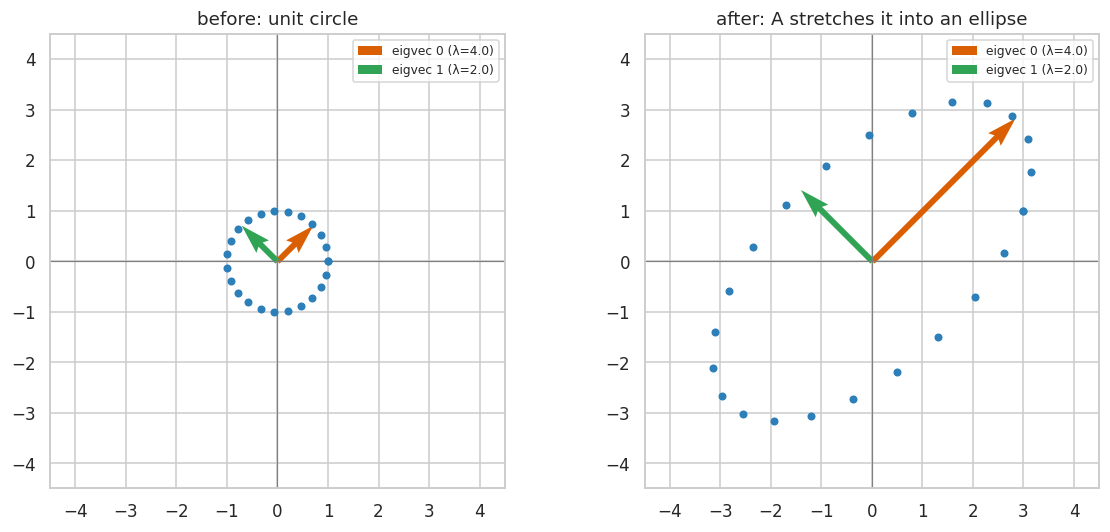

In [20]:
# Picture it: a grid of vectors, before and after applying A
theta = np.linspace(0, 2 * np.pi, 24)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
transformed = circle @ A.T

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pts, title in [(axes[0], circle, "before: unit circle"),
                       (axes[1], transformed, "after: A stretches it into an ellipse")]:
    ax.scatter(pts[:, 0], pts[:, 1], s=18, color="#2c7fb8", zorder=3)
    for i in range(2):
        v = vecs[:, i] * (1 if pts is circle else vals[i])
        ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
                  color=["#d95f02", "#31a354"][i], width=0.013,
                  label=f"eigvec {i} (λ={vals[i]:.1f})")
    ax.set_aspect("equal"); ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
    ax.axhline(0, color="gray", lw=.8); ax.axvline(0, color="gray", lw=.8)
    ax.set_title(title); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Notice the eigenvector arrows point in the **same direction** in both panels — they were
only scaled. Every other point rotated.

## C2 · PCA by hand

**Principal Component Analysis** in four steps:

1. Standardise the features (else the biggest-scaled column dominates).
2. Compute the covariance matrix $C = \frac{1}{n-1}X_z^TX_z$.
3. Eigendecompose `C`; sort eigenvalues descending.
4. Project the data onto the top-k eigenvectors.

The fraction of total variance kept by component `i` is $\lambda_i / \sum_j \lambda_j$.

In [21]:
# Use more features so PCA has something interesting to compress
PCA_FEATURES = ["study_hours_per_day", "social_media_hours", "netflix_hours",
                "attendance_percentage", "sleep_hours", "exercise_frequency",
                "mental_health_rating"]
Xp = df[PCA_FEATURES].to_numpy(dtype=float)

# Step 1: standardise
Xp_z = (Xp - Xp.mean(axis=0)) / Xp.std(axis=0, ddof=1)

# Step 2: covariance
C = np.cov(Xp_z, rowvar=False)
print("covariance matrix shape:", C.shape)

# Step 3: eigendecomposition (eigh = for symmetric matrices, returns sorted ascending)
eigvals, eigvecs = np.linalg.eigh(C)
order = np.argsort(eigvals)[::-1]                # sort descending
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

explained = eigvals / eigvals.sum()
print("\neigenvalues       :", eigvals.round(3))
print("explained variance:", (explained * 100).round(1), "%")
print("cumulative        :", (np.cumsum(explained) * 100).round(1), "%")

covariance matrix shape: (7, 7)

eigenvalues       : [1.084 1.04  1.025 0.993 0.973 0.944 0.941]
explained variance: [15.5 14.9 14.6 14.2 13.9 13.5 13.4] %
cumulative        : [ 15.5  30.3  45.   59.2  73.1  86.6 100. ] %


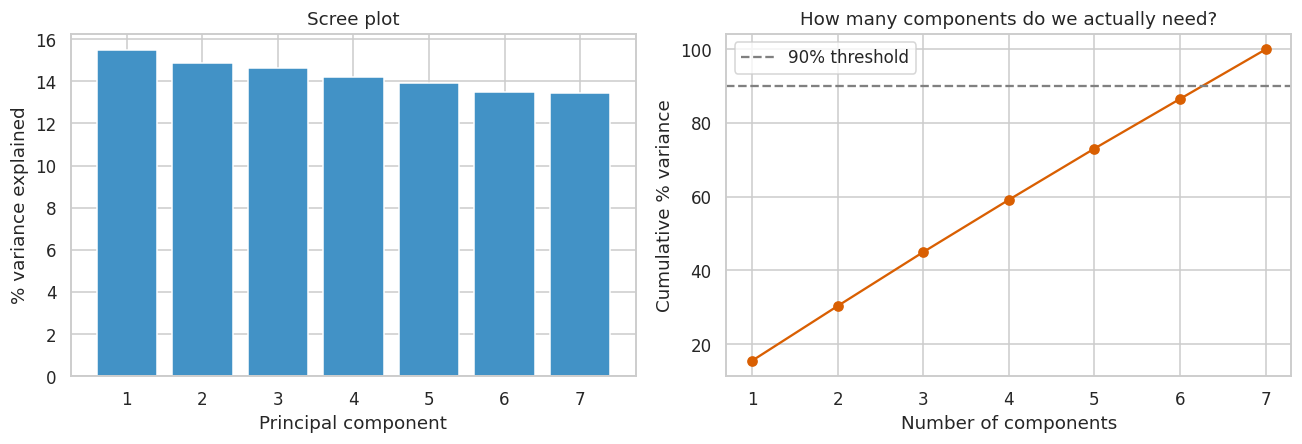

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(range(1, len(eigvals) + 1), explained * 100, color="#4292c6")
axes[0].set_xlabel("Principal component"); axes[0].set_ylabel("% variance explained")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(eigvals) + 1), np.cumsum(explained) * 100,
             marker="o", color="#d95f02")
axes[1].axhline(90, ls="--", color="gray", label="90% threshold")
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative % variance")
axes[1].set_title("How many components do we actually need?")
axes[1].legend()

fig.tight_layout(); plt.show()

projected shape: (1000, 2)  -> 7 features compressed to 2 numbers per student


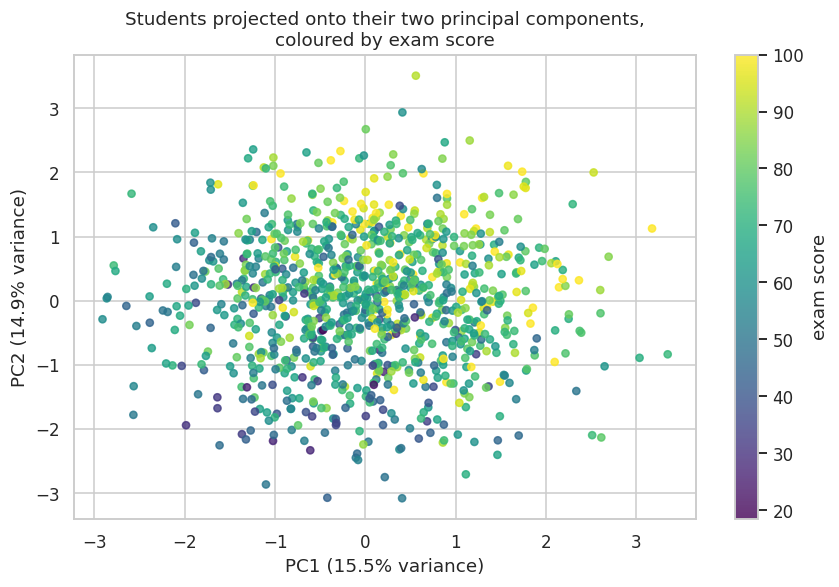

Correlation of PC1 with exam score: 0.256


In [23]:
# Step 4: project onto the first 2 components
Z = Xp_z @ eigvecs[:, :2]
print("projected shape:", Z.shape, " -> 7 features compressed to 2 numbers per student")

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="viridis", s=22, alpha=0.8)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
ax.set_title("Students projected onto their two principal components,\ncoloured by exam score")
fig.colorbar(sc, ax=ax, label="exam score")
fig.tight_layout(); plt.show()

print("Correlation of PC1 with exam score:", np.corrcoef(Z[:, 0], y)[0, 1].round(3))

                         PC1    PC2    PC3
study_hours_per_day    0.504  0.413  0.184
social_media_hours     0.526 -0.361 -0.231
netflix_hours         -0.103 -0.334 -0.628
attendance_percentage  0.475 -0.333  0.236
sleep_hours           -0.073 -0.655  0.234
exercise_frequency    -0.462 -0.164  0.413
mental_health_rating  -0.123  0.143 -0.487


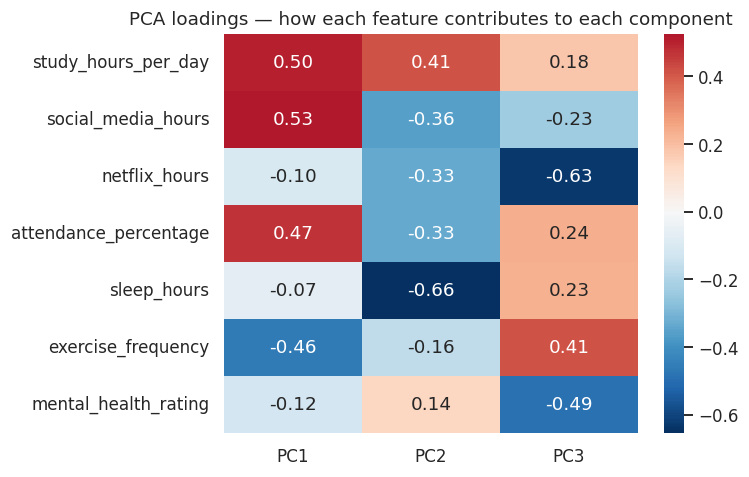

In [24]:
# What do the components MEAN? Read the loadings (the eigenvector entries).
loadings = pd.DataFrame(eigvecs[:, :3].round(3),
                        index=PCA_FEATURES, columns=["PC1", "PC2", "PC3"])
print(loadings)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(loadings, annot=True, cmap="RdBu_r", center=0, ax=ax, fmt=".2f")
ax.set_title("PCA loadings — how each feature contributes to each component")
fig.tight_layout(); plt.show()

In [25]:
# Confirm against sklearn (signs of eigenvectors are arbitrary, so compare |values|)
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(Xp_z)
print("sklearn explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("our explained variance ratio    :", explained[:2].round(4))
print("\nloadings match (up to sign)?    :",
      np.allclose(np.abs(pca.components_.T), np.abs(eigvecs[:, :2])))

sklearn explained variance ratio: [0.1548 0.1486]
our explained variance ratio    : [0.1548 0.1486]

loadings match (up to sign)?    : True


### Bonus: SVD, the more general tool

Every matrix — square or not — factors as $X = U\Sigma V^T$. The columns of `V` are the
principal directions and $\sigma_i^2/(n-1)$ are the eigenvalues of the covariance matrix.
scikit-learn's PCA actually uses SVD, because it never has to form $X^TX$.

In [26]:
U, sigma, Vt = np.linalg.svd(Xp_z, full_matrices=False)
print("U:", U.shape, " sigma:", sigma.shape, " Vt:", Vt.shape)
print("\nsingular values:", sigma.round(2))
print("sigma^2/(n-1)  :", (sigma ** 2 / (len(Xp_z) - 1)).round(3))
print("our eigenvalues:", eigvals.round(3), " <- the same numbers")

U: (1000, 7)  sigma: (7,)  Vt: (7, 7)

singular values: [32.9  32.24 32.   31.5  31.18 30.7  30.66]
sigma^2/(n-1)  : [1.084 1.04  1.025 0.993 0.973 0.944 0.941]
our eigenvalues: [1.084 1.04  1.025 0.993 0.973 0.944 0.941]  <- the same numbers


---
# Part D · Derivatives and gradients

## D1 · The derivative

The derivative $f'(x)$ is the **slope** of `f` at `x` — how fast the output changes when
you nudge the input:

$$f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$$

For ML the reading is: *"if I increase this parameter slightly, does my loss go up or
down, and how fast?"* Slope positive → go left. Slope negative → go right. That single
sentence **is** gradient descent.

In [27]:
def f(x):
    return x ** 2 - 4 * x + 7          # a simple bowl, minimum at x = 2

def f_prime_analytic(x):
    return 2 * x - 4                   # by the power rule

def f_prime_numeric(func, x, h=1e-6):
    """Central difference — more accurate than the forward difference."""
    return (func(x + h) - func(x - h)) / (2 * h)

for x0 in [-1, 0, 2, 5]:
    print(f"x={x0:>3}:  analytic {f_prime_analytic(x0):>6.3f}   "
          f"numeric {f_prime_numeric(f, x0):>9.6f}")
print("\nAt x=2 the slope is 0 -> that is the minimum.")

x= -1:  analytic -6.000   numeric -6.000000
x=  0:  analytic -4.000   numeric -4.000000
x=  2:  analytic  0.000   numeric  0.000000
x=  5:  analytic  6.000   numeric  6.000000

At x=2 the slope is 0 -> that is the minimum.


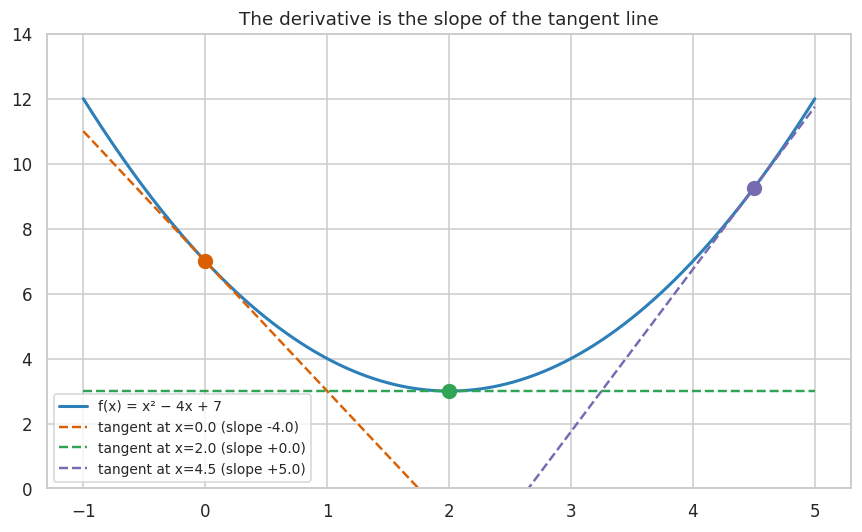

In [28]:
xs = np.linspace(-1, 5, 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, f(xs), color="#2c7fb8", lw=2, label="f(x) = x² − 4x + 7")

for x0, colr in zip([0.0, 2.0, 4.5], ["#d95f02", "#31a354", "#756bb1"]):
    slope = f_prime_analytic(x0)
    tangent = f(x0) + slope * (xs - x0)
    ax.plot(xs, tangent, "--", color=colr, lw=1.6,
            label=f"tangent at x={x0} (slope {slope:+.1f})")
    ax.plot(x0, f(x0), "o", color=colr, ms=9)

ax.set_ylim(0, 14); ax.legend(fontsize=9)
ax.set_title("The derivative is the slope of the tangent line")
fig.tight_layout(); plt.show()

### Rules you will actually use

| Rule | Statement |
|---|---|
| Power | $\frac{d}{dx}x^n = nx^{n-1}$ |
| Sum | $(f+g)' = f' + g'$ |
| Product | $(fg)' = f'g + fg'$ |
| Chain | $\frac{d}{dx}f(g(x)) = f'(g(x))\,g'(x)$ |
| Exponential | $\frac{d}{dx}e^x = e^x$ |
| Log | $\frac{d}{dx}\ln x = 1/x$ |
| Sigmoid | $\sigma'(x) = \sigma(x)(1-\sigma(x))$ ← used in every logistic/NN derivation |

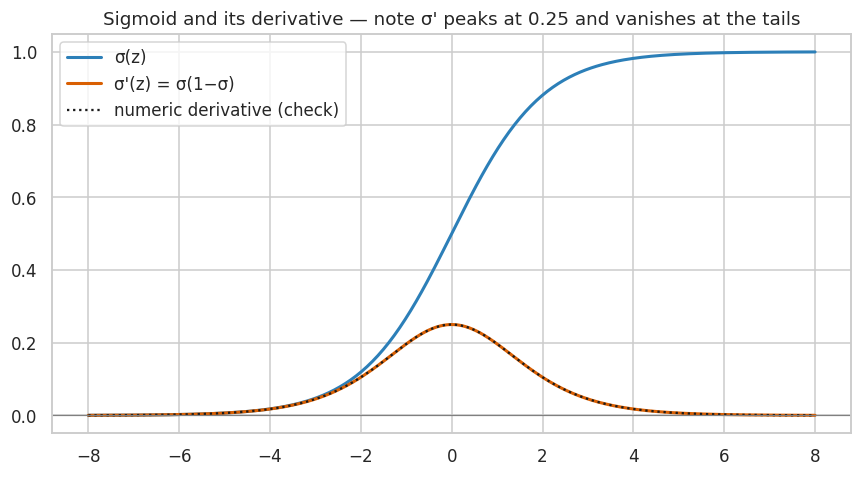

Max of σ' is 0.25 at z=0.
This shrinking-to-zero is the *vanishing gradient* problem in deep networks.


In [29]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

zs = np.linspace(-8, 8, 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(zs, sigmoid(zs), lw=2, color="#2c7fb8", label="σ(z)")
ax.plot(zs, sigmoid_prime(zs), lw=2, color="#d95f02", label="σ'(z) = σ(1−σ)")
ax.plot(zs, [f_prime_numeric(sigmoid, z) for z in zs], "k:", lw=1.5,
        label="numeric derivative (check)")
ax.axhline(0, color="gray", lw=.8)
ax.set_title("Sigmoid and its derivative — note σ' peaks at 0.25 and vanishes at the tails")
ax.legend(); fig.tight_layout(); plt.show()

print("Max of σ' is", sigmoid_prime(0), "at z=0.")
print("This shrinking-to-zero is the *vanishing gradient* problem in deep networks.")

## D2 · Partial derivatives and the gradient

With several parameters, differentiate with respect to **one at a time**, holding the
others fixed — that is a **partial derivative** $\partial f/\partial w_i$.

Stack them into a vector and you have the **gradient**:

$$\nabla f = \begin{bmatrix}\partial f/\partial w_1 \\ \vdots \\ \partial f/\partial w_n\end{bmatrix}$$

**The gradient points in the direction of steepest *increase*.** So to *minimise* a loss,
you step in the direction $-\nabla f$. That is the whole algorithm.

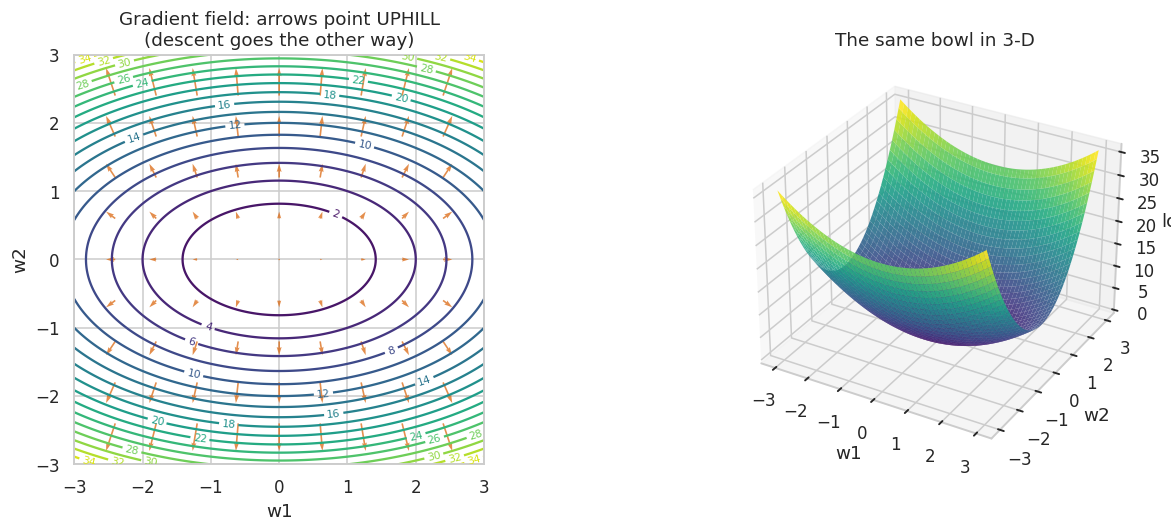

gradient at (2, 1): [4 6]  -> steepest ascent direction
we would step towards [-4 -6]


In [30]:
def g(w1, w2):
    return w1 ** 2 + 3 * w2 ** 2          # an elliptical bowl

def grad_g(w1, w2):
    return np.array([2 * w1, 6 * w2])     # [df/dw1, df/dw2]

W1, W2 = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Zg = g(W1, W2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cs = axes[0].contour(W1, W2, Zg, levels=18, cmap="viridis")
axes[0].clabel(cs, inline=True, fontsize=7)
q1, q2 = np.meshgrid(np.linspace(-3, 3, 11), np.linspace(-3, 3, 11))
gu, gv = 2 * q1, 6 * q2
axes[0].quiver(q1, q2, gu, gv, color="#d95f02", alpha=0.7, width=0.004)
axes[0].set_title("Gradient field: arrows point UPHILL\n(descent goes the other way)")
axes[0].set_xlabel("w1"); axes[0].set_ylabel("w2"); axes[0].set_aspect("equal")

ax3d = fig.add_subplot(1, 2, 2, projection="3d")
axes[1].remove()
ax3d.plot_surface(W1, W2, Zg, cmap="viridis", alpha=0.9, linewidth=0)
ax3d.set_xlabel("w1"); ax3d.set_ylabel("w2"); ax3d.set_zlabel("loss")
ax3d.set_title("The same bowl in 3-D")

fig.tight_layout(); plt.show()

print("gradient at (2, 1):", grad_g(2, 1), " -> steepest ascent direction")
print("we would step towards", -grad_g(2, 1))

## D3 · The gradient of Mean Squared Error

This is the derivation that makes linear regression trainable. With

$$L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \mathbf{w}\cdot\mathbf{x}_i - b)^2$$

apply the chain rule (outer: square, inner: the linear term):

$$\frac{\partial L}{\partial \mathbf{w}} = -\frac{2}{n}X^T(\mathbf{y}-\hat{\mathbf{y}}),
\qquad
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_i(y_i-\hat{y}_i)$$

Two lines of NumPy. Let's verify them numerically before trusting them.

In [31]:
# Standardise the features so all gradients are on a comparable scale
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
Xs = (X - X_mean) / X_std
n = len(Xs)

def mse_loss(w, b, Xm=Xs, yv=y):
    return np.mean((yv - (Xm @ w + b)) ** 2)

def mse_gradients(w, b, Xm=Xs, yv=y):
    residual = yv - (Xm @ w + b)
    dw = -2 / len(Xm) * (Xm.T @ residual)
    db = -2 / len(Xm) * residual.sum()
    return dw, db

w_test = np.array([1.0, -0.5, 0.3, 0.2, 2.0])
b_test = 60.0

dw, db = mse_gradients(w_test, b_test)
print("analytic dL/dw:", dw.round(5))
print("analytic dL/db:", round(db, 5))

# Numeric gradient check — always do this when you derive gradients by hand
eps = 1e-5
dw_num = np.array([
    (mse_loss(w_test + eps * np.eye(len(w_test))[i], b_test)
     - mse_loss(w_test - eps * np.eye(len(w_test))[i], b_test)) / (2 * eps)
    for i in range(len(w_test))
])
db_num = (mse_loss(w_test, b_test + eps) - mse_loss(w_test, b_test - eps)) / (2 * eps)

print("\nnumeric  dL/dw:", dw_num.round(5))
print("numeric  dL/db:", round(db_num, 5))
print("\nmatch? ", np.allclose(dw, dw_num, atol=1e-4) and abs(db - db_num) < 1e-4)

analytic dL/dw: [-25.7338   -5.09797   6.41778   6.13645   1.02935]
analytic dL/db: -19.203

numeric  dL/dw: [-25.7338   -5.09797   6.41778   6.13645   1.02935]
numeric  dL/db: -19.203

match?  True


---
# Part E · The chain rule → backpropagation

## E1 · The rule

If $z = f(g(x))$ then

$$\frac{dz}{dx} = \frac{dz}{dg}\cdot\frac{dg}{dx}$$

Derivatives **multiply along the path**. A neural network is just a long composition of
functions, so its gradient is a long product of local derivatives — computed right to
left. That backward sweep is **backpropagation**.

In [32]:
# z = (3x + 1)^2 , computed as a chain:  u = 3x+1  ->  z = u^2
def h(x):
    u = 3 * x + 1
    return u ** 2

def h_prime_chain(x):
    u = 3 * x + 1
    dz_du = 2 * u        # outer derivative
    du_dx = 3            # inner derivative
    return dz_du * du_dx

for x0 in [0.0, 1.0, 2.5]:
    print(f"x={x0}:  chain rule {h_prime_chain(x0):>8.3f}   "
          f"numeric {f_prime_numeric(h, x0):>10.5f}")

x=0.0:  chain rule    6.000   numeric    6.00000
x=1.0:  chain rule   24.000   numeric   24.00000
x=2.5:  chain rule   51.000   numeric   51.00000


## E2 · Backprop through one neuron, by hand

The tiniest possible network:

$$
x \;\xrightarrow{\;w,b\;}\; z = wx+b \;\xrightarrow{\;\sigma\;}\; a = \sigma(z) \;\longrightarrow\; L = (a-t)^2
$$

**Forward pass** computes `z → a → L`. **Backward pass** multiplies local derivatives
back down the chain:

$$\frac{\partial L}{\partial w}
= \underbrace{\frac{\partial L}{\partial a}}_{2(a-t)}
\cdot \underbrace{\frac{\partial a}{\partial z}}_{\sigma(z)(1-\sigma(z))}
\cdot \underbrace{\frac{\partial z}{\partial w}}_{x}$$

In [33]:
x_in, target = 1.5, 1.0
w, b = 0.8, -0.2

# ---- FORWARD ----
z = w * x_in + b
a = sigmoid(z)
L = (a - target) ** 2
print(f"FORWARD :  z = {z:.4f}  ->  a = {a:.4f}  ->  L = {L:.6f}")

# ---- BACKWARD (chain rule, one factor at a time) ----
dL_da = 2 * (a - target)
da_dz = a * (1 - a)              # sigmoid derivative, reusing the forward value
dz_dw = x_in
dz_db = 1.0

dL_dz = dL_da * da_dz
dL_dw = dL_dz * dz_dw
dL_db = dL_dz * dz_db

print("\nBACKWARD:")
print(f"  dL/da = 2(a-t)        = {dL_da:.6f}")
print(f"  da/dz = a(1-a)        = {da_dz:.6f}")
print(f"  dL/dz = dL/da * da/dz = {dL_dz:.6f}")
print(f"  dL/dw = dL/dz * x     = {dL_dw:.6f}")
print(f"  dL/db = dL/dz * 1     = {dL_db:.6f}")

# Numeric check
def loss_of(w_, b_):
    return (sigmoid(w_ * x_in + b_) - target) ** 2

eps = 1e-6
print("\nnumeric dL/dw =", round((loss_of(w+eps, b) - loss_of(w-eps, b)) / (2*eps), 6))
print("numeric dL/db =", round((loss_of(w, b+eps) - loss_of(w, b-eps)) / (2*eps), 6))
print("\nHand-derived gradients confirmed.")

FORWARD :  z = 1.0000  ->  a = 0.7311  ->  L = 0.072329

BACKWARD:
  dL/da = 2(a-t)        = -0.537883
  da/dz = a(1-a)        = 0.196612
  dL/dz = dL/da * da/dz = -0.105754
  dL/dw = dL/dz * x     = -0.158631
  dL/db = dL/dz * 1     = -0.105754

numeric dL/dw = -0.158631
numeric dL/db = -0.105754

Hand-derived gradients confirmed.


## E3 · A real 2-layer network in pure NumPy

Now scale the same idea up: predict **pass / fail** from standardised habits with one
hidden layer. Forward pass, backward pass, weight update — no framework, ~30 lines.

$$
X \to Z_1 = XW_1+b_1 \to A_1 = \text{ReLU}(Z_1) \to Z_2 = A_1W_2+b_2 \to \hat{y}=\sigma(Z_2)
$$

pass rate: 0.72



final loss 0.2648 | training accuracy 0.898

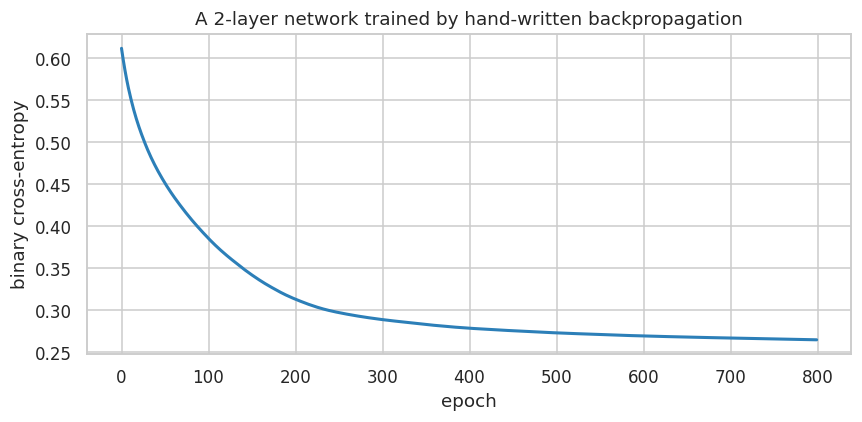

In [34]:
y_binary = (y >= 60).astype(float).reshape(-1, 1)
print("pass rate:", y_binary.mean().round(3))

rng = np.random.default_rng(0)
n_in, n_hidden = Xs.shape[1], 8

# He initialisation for ReLU layers
W1 = rng.normal(0, np.sqrt(2 / n_in), size=(n_in, n_hidden))
b1 = np.zeros((1, n_hidden))
W2 = rng.normal(0, np.sqrt(2 / n_hidden), size=(n_hidden, 1))
b2 = np.zeros((1, 1))

def relu(z):
    return np.maximum(0, z)

lr, epochs = 0.1, 800
history = []

for epoch in range(epochs):
    # ---------- FORWARD ----------
    Z1 = Xs @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    yhat = sigmoid(Z2)

    # binary cross-entropy (clipped to avoid log(0))
    p = np.clip(yhat, 1e-9, 1 - 1e-9)
    loss = -np.mean(y_binary * np.log(p) + (1 - y_binary) * np.log(1 - p))
    history.append(loss)

    # ---------- BACKWARD (chain rule, layer by layer) ----------
    m = len(Xs)
    dZ2 = (yhat - y_binary) / m         # sigmoid + BCE collapse to this neat form
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)                # derivative of ReLU is 1 where z>0, else 0
    dW1 = Xs.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    # ---------- UPDATE ----------
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

acc = ((yhat > 0.5).astype(float) == y_binary).mean()
print(f"\nfinal loss {history[-1]:.4f} | training accuracy {acc:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, color="#2c7fb8", lw=2)
ax.set_xlabel("epoch"); ax.set_ylabel("binary cross-entropy")
ax.set_title("A 2-layer network trained by hand-written backpropagation")
fig.tight_layout(); plt.show()

> That loop is what PyTorch's `loss.backward()` automates. You now know what it does.

---
# Part F · Gradient descent, end to end

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla_{\mathbf{w}}L$$

`η` (eta) is the **learning rate**:

- too small → crawls, may never arrive
- too large → overshoots, oscillates, or diverges to NaN
- just right → smooth exponential-looking decay

Let's train linear regression on the real data and *watch* it converge to the closed-form
answer we computed in Part B.

In [35]:
def gradient_descent(Xm, yv, lr=0.1, epochs=300, seed=0):
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.01, size=Xm.shape[1])
    b = 0.0
    losses, path = [], []
    for _ in range(epochs):
        dw, db = mse_gradients(w, b, Xm, yv)
        w = w - lr * dw
        b = b - lr * db
        losses.append(mse_loss(w, b, Xm, yv))
        path.append(np.concatenate([[b], w]))
    return w, b, np.array(losses), np.array(path)


w_gd, b_gd, losses, path = gradient_descent(Xs, y, lr=0.1, epochs=400)

print(f"gradient descent : b = {b_gd:.3f}, w = {w_gd.round(3)}")
print(f"final MSE        : {losses[-1]:.4f}")

# Compare with the closed-form solution on the SAME standardised features
Xs_design = np.column_stack([np.ones(len(Xs)), Xs])
w_exact = np.linalg.lstsq(Xs_design, y, rcond=None)[0]
print(f"\nclosed form      : b = {w_exact[0]:.3f}, w = {w_exact[1:].round(3)}")
print("gradient descent converged to the exact solution:",
      np.allclose(w_gd, w_exact[1:], atol=1e-2))

gradient descent : b = 69.601, w = [13.958  2.48  -3.165 -2.424  1.239]
final MSE        : 67.5496

closed form      : b = 69.602, w = [13.958  2.48  -3.165 -2.424  1.239]
gradient descent converged to the exact solution: True


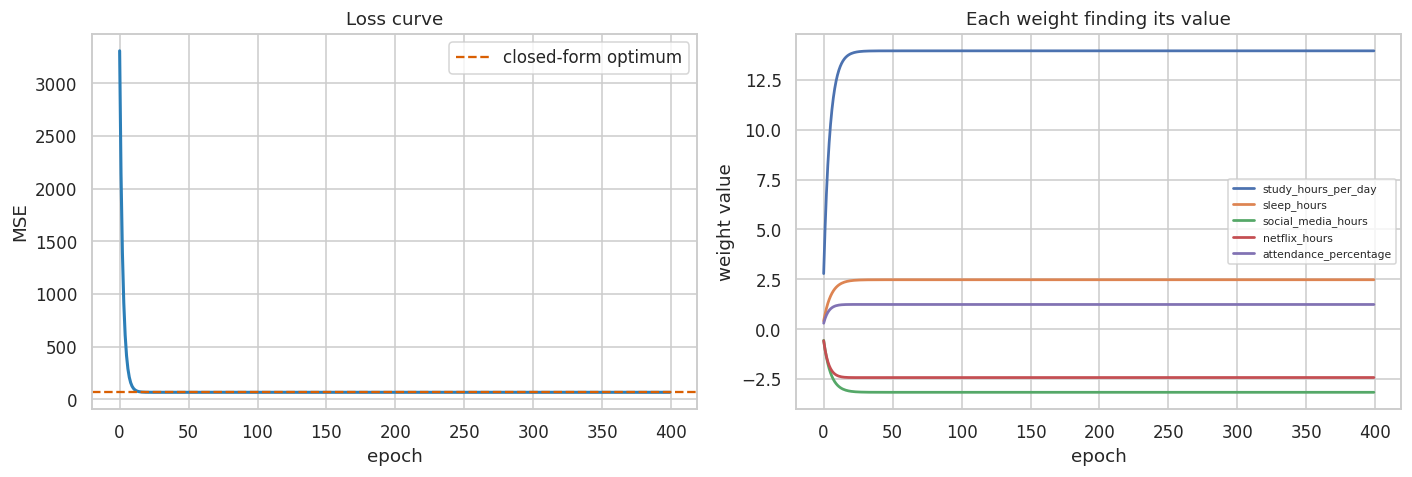

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(losses, color="#2c7fb8", lw=2)
axes[0].axhline(mse_loss(w_exact[1:], w_exact[0]), ls="--", color="#d95f02",
                label="closed-form optimum")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("Loss curve"); axes[0].legend()

for i, name in enumerate(FEATURES):
    axes[1].plot(path[:, i + 1], label=name, lw=1.8)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("weight value")
axes[1].set_title("Each weight finding its value")
axes[1].legend(fontsize=7)

fig.tight_layout(); plt.show()

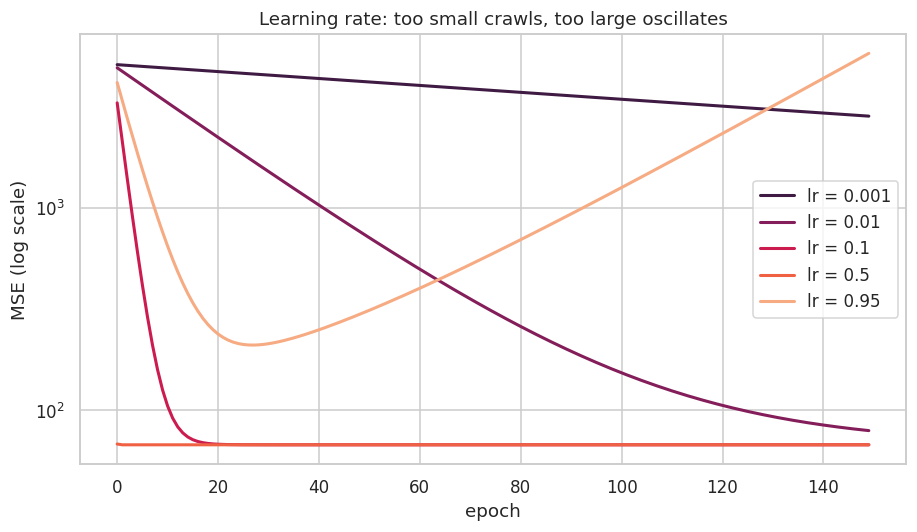

In [37]:
# The learning-rate experiment every ML student should run once
fig, ax = plt.subplots(figsize=(8.5, 5))
for lr, colr in zip([0.001, 0.01, 0.1, 0.5, 0.95], sns.color_palette("rocket", 5)):
    _, _, L, _ = gradient_descent(Xs, y, lr=lr, epochs=150)
    ax.plot(L, label=f"lr = {lr}", color=colr, lw=2)
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Learning rate: too small crawls, too large oscillates")
ax.legend(); fig.tight_layout(); plt.show()

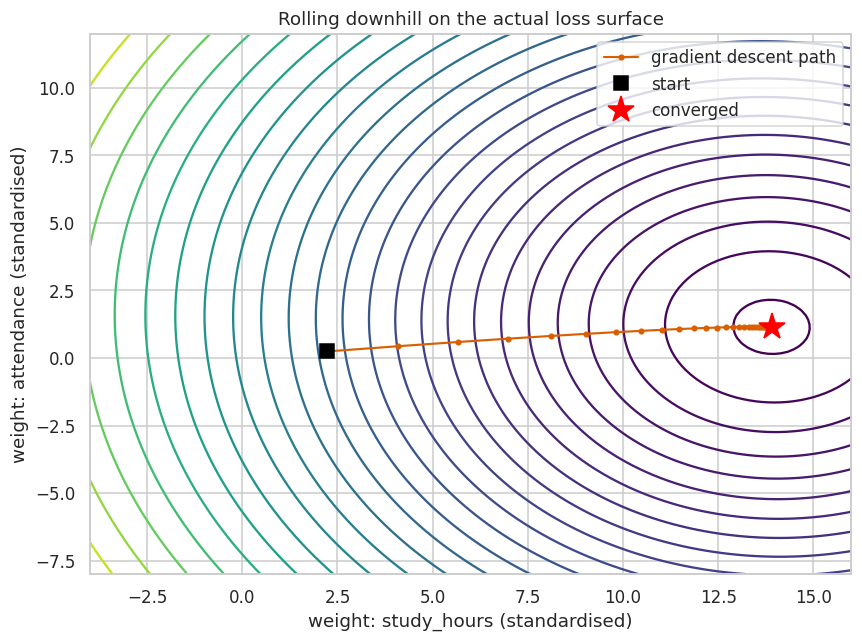

In [38]:
# See the descent path on a 2-D slice of the loss surface (study hours & attendance)
idx = [0, 4]
X2 = Xs[:, idx]

def loss2(w0, w1, b=y.mean()):
    return np.mean((y - (X2 @ np.array([w0, w1]) + b)) ** 2)

g0 = np.linspace(-4, 16, 120)
g1 = np.linspace(-8, 12, 120)
G0, G1 = np.meshgrid(g0, g1)
LS = np.array([[loss2(a_, b_) for a_ in g0] for b_ in g1])

w2, b2_, _, path2 = gradient_descent(X2, y, lr=0.08, epochs=120)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(G0, G1, LS, levels=np.logspace(np.log10(LS.min()+1), np.log10(LS.max()), 25),
                cmap="viridis")
ax.plot(path2[:, 1], path2[:, 2], "o-", color="#d95f02", ms=3, lw=1.4,
        label="gradient descent path")
ax.plot(path2[0, 1], path2[0, 2], "s", color="black", ms=9, label="start")
ax.plot(path2[-1, 1], path2[-1, 2], "*", color="red", ms=18, label="converged")
ax.set_xlabel("weight: study_hours (standardised)")
ax.set_ylabel("weight: attendance (standardised)")
ax.set_title("Rolling downhill on the actual loss surface")
ax.legend(); fig.tight_layout(); plt.show()

---
## Mini-challenge

1. Compute the **Euclidean distance** matrix between the first 50 standardised students
   using broadcasting only (`(A[:,None,:] - A[None,:,:])**2`), no loops. Verify against
   `scipy.spatial.distance.cdist`.
2. Add **L2 regularisation** to `mse_gradients`: the loss becomes
   $L + \alpha\|\mathbf{w}\|^2$, so the gradient gains $2\alpha\mathbf{w}$. Train with
   `alpha = 0, 0.1, 1, 10` and plot how the weights shrink. (This is Ridge — Week 7.)
3. Implement **mini-batch** gradient descent: shuffle the data and update on batches of 32.
   Compare its loss curve to full-batch.
4. Derive $\partial L/\partial w$ for **logistic regression** with binary cross-entropy by
   hand, then verify numerically. (Hint: it simplifies to $X^T(\hat{y}-y)/n$.)
5. Reconstruct the data from only 3 principal components and measure the reconstruction
   error $\|X_z - X_{\text{recon}}\|_F$.

In [39]:
# --- your workspace for the mini-challenge ---

---
## Recap

| Concept | What it *means* in ML |
|---|---|
| Vector | one sample; a point and a direction |
| Norm | size of a vector; L1 → Lasso, L2 → Ridge |
| Dot product | similarity, and the core of every prediction $\mathbf{w}\cdot\mathbf{x}$ |
| Orthogonality | uncorrelated directions; residual ⟂ fitted values |
| Matrix | the dataset; `X @ w` predicts all rows at once |
| Transpose | `X.T @ X` = Gram / covariance matrix |
| Determinant = 0 | singular, not invertible → multicollinearity |
| Normal equation | $\mathbf{w}=(X^TX)^{-1}X^T\mathbf{y}$, closed-form regression |
| Eigenvector | a direction of variation in the data |
| Eigenvalue | how much variance lies along it |
| PCA | keep the top-k eigenvectors, drop the rest |
| Derivative | slope: "which way improves my loss?" |
| Gradient | vector of partials; points uphill, so step **against** it |
| Chain rule | derivatives multiply along a path = backpropagation |
| Learning rate | step size; the most important hyperparameter you will tune |

**Key numbers from this notebook:** the closed-form linear model reaches R² ≈ 0.76 on
these five features alone, and the first two principal components explain only ~30% of the
habit variance. That second number is important: the habits are *almost uncorrelated* with
each other, so PCA has very little redundancy to squeeze out here — which is exactly why
plain linear regression already does well.

**Next:** `week07_08_regression_classification.ipynb` — where scikit-learn does all of
this for you, and you finally get to say *why* it works.